In [1]:
import re
import os
import pandas as pd
from glob import glob

def parse_modsec_log(filepath):
    with open(filepath, encoding='utf-8', errors='replace') as f:
        content = f.read()

    entries = re.split(r'--[a-f0-9]+-A--', content)
    records = []

    for entry in entries:
        if not entry.strip():
            continue

        record = {}

        # timestamp, IPs
        a_match = re.match(
            r'\[([^\]]+)\]\s+(\S+)\s+(\S+)\s+(\d+)\s+(\S+)\s+(\d+)',
            entry.strip()
        )
        if a_match:
            record['timestamp']  = a_match.group(1)
            record['unique_id']  = a_match.group(2)
            record['src_ip']     = a_match.group(3)
            record['src_port']   = a_match.group(4)
            record['dst_ip']     = a_match.group(5)
            record['dst_port']   = a_match.group(6)

        # metodo, URI, protocolo
        b_section = re.search(r'--[a-f0-9]+-B--(.*?)--[a-f0-9]+-', entry, re.DOTALL)
        if b_section:
            b = b_section.group(1).strip()
            req_line = re.match(r'(GET|POST|PUT|DELETE|HEAD|OPTIONS|PATCH)\s+(\S+)\s+(HTTP/\S+)', b)
            if req_line:
                record['method']   = req_line.group(1)
                record['uri']      = req_line.group(2)
                record['protocol'] = req_line.group(3)
            host_match = re.search(r'^Host:\s*(.+)$', b, re.MULTILINE)
            if host_match:
                record['host'] = host_match.group(1).strip()
            ua_match = re.search(r'^User-Agent:\s*(.+)$', b, re.MULTILINE)
            if ua_match:
                record['user_agent'] = ua_match.group(1).strip()

        # status code
        f_section = re.search(r'--[a-f0-9]+-F--(.*?)--[a-f0-9]+-', entry, re.DOTALL)
        if f_section:
            status_match = re.search(r'HTTP/\S+\s+(\d{3})', f_section.group(1))
            if status_match:
                record['status_code'] = status_match.group(1)

        # reglas disparadas, severidad, tags
        h_section = re.search(r'--[a-f0-9]+-H--(.*?)--[a-f0-9]+-Z--', entry, re.DOTALL)
        if h_section:
            h = h_section.group(1)

            rule_ids  = re.findall(r'\[id "(\d+)"\]', h)
            msgs      = re.findall(r'\[msg "([^"]+)"\]', h)
            severities= re.findall(r'\[severity "([^"]+)"\]', h)
            tags      = re.findall(r'\[tag "([^"]+)"\]', h)
            data      = re.findall(r'\[data "([^"]+)"\]', h)

            record['rule_ids']   = ','.join(rule_ids)
            record['messages']   = ' | '.join(msgs)
            record['severities'] = ','.join(set(severities))
            record['tags']       = ','.join(set(tags))
            record['data']       = ' | '.join(data)
            record['rule_count'] = len(rule_ids)

        if record:
            records.append(record)

    return records

log_root = '../data/owasp'
all_records = []

log_files = glob(os.path.join(log_root, '**', '*.log'), recursive=True)
print(f"Archivos encontrados: {len(log_files)}")

for i, filepath in enumerate(sorted(log_files)):
    date_folder = os.path.basename(os.path.dirname(filepath))
    print(f"  Procesando [{i+1}/{len(log_files)}]: {date_folder}")
    records = parse_modsec_log(filepath)
    for r in records:
        r['source_date'] = date_folder
        r['source_file'] = filepath
    all_records.extend(records)

df = pd.DataFrame(all_records)
df.to_csv('../data/modsec_logs_dataset.csv', index=False, encoding='utf-8')

print(f"\nTotal registros: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
print()
print(df.head(3).to_string())

Archivos encontrados: 30
  Procesando [1/30]: 01-Aug-2025
  Procesando [2/30]: 02-Aug-2025
  Procesando [3/30]: 03-Aug-2025
  Procesando [4/30]: 04-Aug-2025
  Procesando [5/30]: 05-Aug-2025
  Procesando [6/30]: 06-Aug-2025
  Procesando [7/30]: 07-Aug-2025
  Procesando [8/30]: 08-Aug-2025
  Procesando [9/30]: 09-Aug-2025
  Procesando [10/30]: 10-Aug-2025
  Procesando [11/30]: 11-Aug-2025
  Procesando [12/30]: 12-Aug-2025
  Procesando [13/30]: 13-Aug-2025
  Procesando [14/30]: 14-Aug-2025
  Procesando [15/30]: 15-Aug-2025
  Procesando [16/30]: 16-Aug-2025
  Procesando [17/30]: 17-Aug-2025
  Procesando [18/30]: 18-Aug-2025
  Procesando [19/30]: 19-Aug-2025
  Procesando [20/30]: 20-Aug-2025
  Procesando [21/30]: 21-Aug-2025
  Procesando [22/30]: 22-Aug-2025
  Procesando [23/30]: 23-Aug-2025
  Procesando [24/30]: 24-Aug-2025
  Procesando [25/30]: 25-Aug-2025
  Procesando [26/30]: 27-Jul-2025
  Procesando [27/30]: 28-Jul-2025
  Procesando [28/30]: 29-Jul-2025
  Procesando [29/30]: 30-Jul-202

=== SHAPE ===
Registros: 142705
Columnas:  ['timestamp', 'unique_id', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'method', 'uri', 'protocol', 'host', 'status_code', 'rule_ids', 'messages', 'severities', 'tags', 'data', 'rule_count', 'source_date', 'source_file', 'user_agent', 'date', 'hour']

=== NULLS ===
timestamp          0
unique_id          0
src_ip             0
src_port           0
dst_ip             0
dst_port           0
method            82
uri               82
protocol          82
host             335
status_code        0
rule_ids           0
messages           3
severities        21
tags           47592
data           57051
rule_count         0
source_date        0
source_file        0
user_agent     13725
date               0
hour               0
dtype: int64

=== METODOS HTTP ===
method
GET        127563
POST        14484
HEAD          499
PUT            47
OPTIONS        12
DELETE         12
PATCH           6
Name: count, dtype: int64

=== STATUS CODES ===
status_code
4

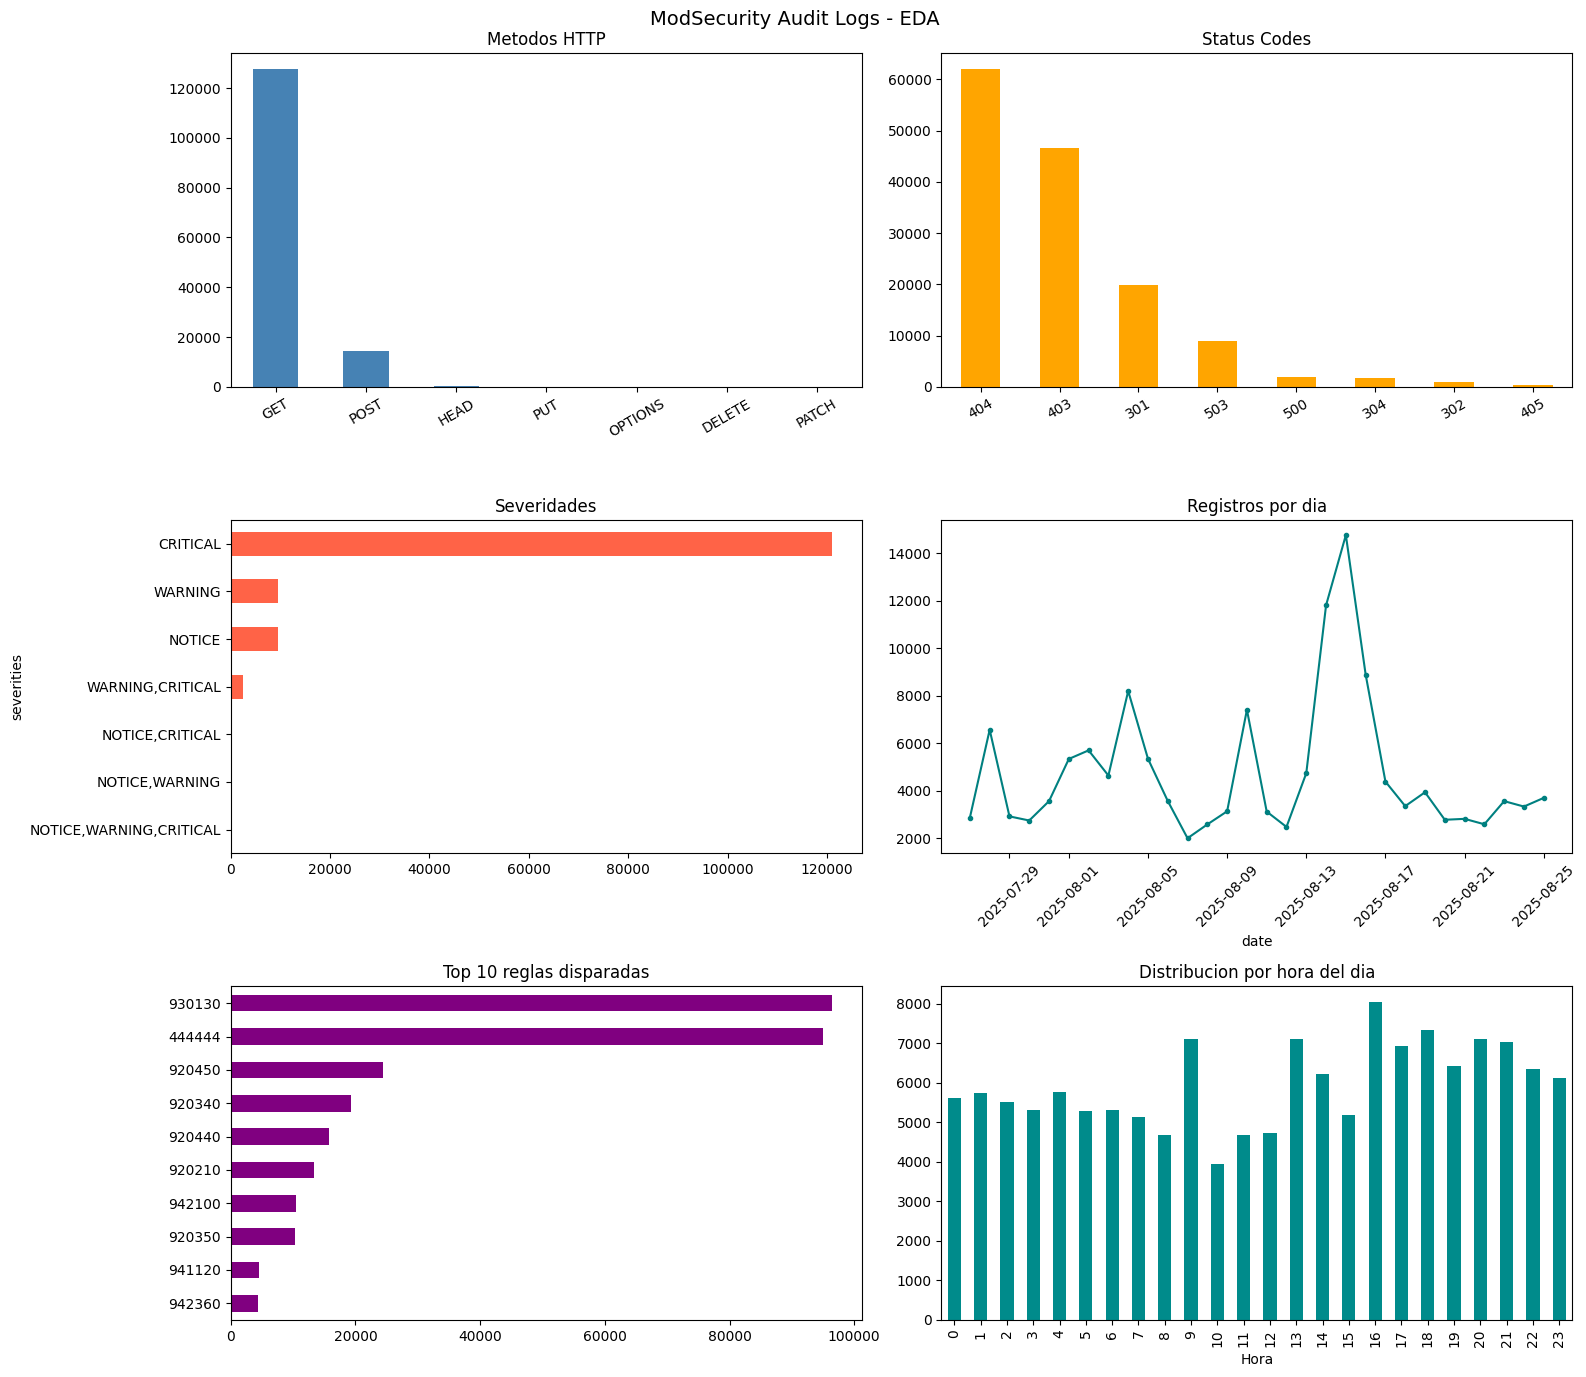


Grafica guardada en ../data/modsec_eda.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

df = pd.read_csv('../data/modsec_logs_dataset.csv', encoding='utf-8')

df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%b/%Y:%H:%M:%S %z', errors='coerce')
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['status_code'] = df['status_code'].astype(str)

print("=== SHAPE ===")
print(f"Registros: {len(df)}")
print(f"Columnas:  {df.columns.tolist()}")

print("\n=== NULLS ===")
print(df.isnull().sum())

print("\n=== METODOS HTTP ===")
print(df['method'].value_counts())

print("\n=== STATUS CODES ===")
print(df['status_code'].value_counts().head(10))

print("\n=== SEVERIDADES ===")
print(df['severities'].value_counts().head(10))

print("\n=== TOP 15 REGLAS DISPARADAS ===")
all_rules = ','.join(df['rule_ids'].dropna()).split(',')
rule_counts = Counter(r for r in all_rules if r.strip())
for rule, count in rule_counts.most_common(15):
    print(f"  {rule}: {count}")

print("\n=== TOP 15 TAGS ===")
all_tags = ','.join(df['tags'].dropna()).split(',')
tag_counts = Counter(t for t in all_tags if t.strip())
for tag, count in tag_counts.most_common(15):
    print(f"  {tag}: {count}")

print("\n=== TOP 10 IPs ORIGEN ===")
print(df['src_ip'].value_counts().head(10))

print("\n=== REGISTROS POR DIA ===")
print(df['date'].value_counts().sort_index())

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('ModSecurity Audit Logs - EDA', fontsize=14)

df['method'].value_counts().head(8).plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Metodos HTTP')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=30)

df['status_code'].value_counts().head(8).plot(kind='bar', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Status Codes')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=30)

sev_counts = df['severities'].value_counts().head(8)
sev_counts.plot(kind='barh', ax=axes[1, 0], color='tomato')
axes[1, 0].set_title('Severidades')
axes[1, 0].invert_yaxis()

daily = df.groupby('date').size()
daily.plot(kind='line', ax=axes[1, 1], color='teal', marker='o', markersize=3)
axes[1, 1].set_title('Registros por dia')
axes[1, 1].tick_params(axis='x', rotation=45)

top_rules = pd.Series(dict(rule_counts.most_common(10)))
top_rules.plot(kind='barh', ax=axes[2, 0], color='purple')
axes[2, 0].set_title('Top 10 reglas disparadas')
axes[2, 0].invert_yaxis()

hourly = df.groupby('hour').size()
hourly.plot(kind='bar', ax=axes[2, 1], color='darkcyan')
axes[2, 1].set_title('Distribucion por hora del dia')
axes[2, 1].set_xlabel('Hora')

plt.tight_layout()
plt.savefig('../data/modsec_eda.png', dpi=150)
plt.show()
print("\nGrafica guardada en ../data/modsec_eda.png")

In [4]:
import pandas as pd
from collections import Counter

df = pd.read_csv('../data/modsec_logs_dataset.csv', encoding='utf-8')

all_rules = ','.join(df['rule_ids'].dropna()).split(',')
rule_counts = Counter(r for r in all_rules if r.strip())

print("=== TODAS LAS REGLAS CON SU MENSAJE ===")
rule_msg = {}
for _, row in df.iterrows():
    if pd.isna(row['rule_ids']) or pd.isna(row['messages']):
        continue
    rules = row['rule_ids'].split(',')
    msgs  = row['messages'].split(' | ')
    for rule, msg in zip(rules, msgs):
        rule = rule.strip()
        if rule and rule not in rule_msg:
            rule_msg[rule] = msg.strip()

for rule, count in rule_counts.most_common(40):
    msg = rule_msg.get(rule, 'sin mensaje')
    print(f"  {rule:10} {count:8}   {msg[:80]}")

=== TODAS LAS REGLAS CON SU MENSAJE ===
  930130        96432   Restricted File Access Attempt
  444444        95072   BAD BOT - Detected and Blocked.
  920450        24376   HTTP header is restricted by policy (/accept-charset/)
  920340        19318   Request Containing Content, but Missing Content-Type header
  920440        15764   URL file extension is restricted by policy
  920210        13420   Multiple/Conflicting Connection Header Data Found.
  942100        10420   SQL Injection Attack Detected via libinjection
  920350        10354   Host header is a numeric IP address
  941120         4566   XSS Filter - Category 2: Event Handler Vector
  942360         4310   Detects concatenated basic SQL injection and SQLLFI attempts
  932150         4176   Remote Command Execution: Direct Unix Command Execution
  920420         3714   Request content type is not allowed by policy
  930110         3680   Path Traversal Attack (/../)
  942160         3260   Detects blind sqli tests using 

In [6]:
import pandas as pd
from collections import Counter

df = pd.read_csv('../data/modsec_logs_dataset.csv', encoding='utf-8')

print("=== IPs con mas de 100 requests (posible fuerza bruta/DDoS) ===")
ip_counts = df['src_ip'].value_counts()
print(ip_counts[ip_counts > 100].head(20))

print("\n=== URIs mas atacadas ===")
print(df['uri'].value_counts().head(20))

print("\n=== Entradas con 444444 - muestra de mensajes ===")
mask = df['rule_ids'].fillna('').str.contains('444444')
print(df[mask][['src_ip', 'uri', 'messages', 'user_agent']].head(10).to_string())

print("\n=== Entradas con 913100 - scanner ===")
mask2 = df['rule_ids'].fillna('').str.contains('913100')
print(df[mask2][['src_ip', 'uri', 'user_agent', 'messages']].head(10).to_string())

=== IPs con mas de 100 requests (posible fuerza bruta/DDoS) ===
src_ip
100.72.246.59      8125
100.104.104.150    7991
100.92.207.135     4885
100.66.85.2        4694
100.68.3.232       3922
100.77.175.132     3213
100.86.166.134     2954
100.85.206.208     2639
100.81.252.4       2599
100.122.171.187    2520
100.118.88.136     2418
100.100.4.143      2207
100.90.178.169     2009
100.73.81.39       1893
100.103.209.183    1849
100.68.195.85      1664
100.111.87.100     1501
100.109.210.18     1315
100.111.185.68     1275
100.117.88.61      1251
Name: count, dtype: int64

=== URIs mas atacadas ===
uri
/robots.txt         17489
/xmlrpc.php          9966
/                    8192
/.env                4517
/.git/config         3917
/api/.env            1420
/.git/HEAD           1231
/d_43826a23           930
/admin/.env           918
/backend/.env         906
/d_c8655413           889
/.env.example         831
/.env.local           758
/wp-login.php         750
/.env.prod            734
/x

In [8]:
import pandas as pd

df = pd.read_csv('../data/modsec_logs_dataset.csv', encoding='utf-8')

BRUTE_FORCE_URIS = ['/wp-login.php', '/xmlrpc.php', '/admin', '/login',
                    '/wp-admin', '/administrator', '/auth', '/signin']

HARVEST_URIS = ['/.env', '/.git/config', '/.git/HEAD', '/.env.example',
                '/.env.local', '/.env.prod', '/.env.bak', '/.env.production',
                '/api/.env', '/backend/.env', '/admin/.env', '/app/.env',
                '/dev/.env', '/robots.txt']

SQLI_RULES    = {'942100','942360','942160','942190','942280'}
XSS_RULES     = {'941120','941110'}
RCE_RULES     = {'932150','932130','932160','932115','932105',
                 '933160','933150','933100','933140','933120',
                 '933110','944130','944110','944100'}
LFI_RULES     = {'930130','930110','930120','930100'}
RFI_RULES     = {'931100'}
BOT_RULES     = {'444444','913100'}
PHP_RULES     = {'933150','933160','933100','933140','933120','933110'}

def classify_log(row):
    rules = set(str(row['rule_ids']).split(',')) if pd.notna(row['rule_ids']) else set()
    uri   = str(row['uri']).lower() if pd.notna(row['uri']) else ''
    ua    = str(row['user_agent']).lower() if pd.notna(row['user_agent']) else ''

    if rules & SQLI_RULES:
        return 'SQLi'
    if rules & XSS_RULES:
        return 'XSS'
    if rules & RCE_RULES:
        return 'RCE/Command Injection'
    if rules & LFI_RULES:
        return 'LFI/Path Traversal'
    if rules & RFI_RULES:
        return 'RFI'
    if any(uri.startswith(u) for u in BRUTE_FORCE_URIS):
        return 'Brute Force'
    if any(uri.startswith(u) for u in HARVEST_URIS):
        return 'Credential Harvesting'
    if rules & BOT_RULES:
        return 'Bad Bot/Reconnaissance'
    if any(k in ua for k in ['zgrab', 'masscan', 'nikto', 'nmap', 'scanner',
                               'sqlmap', 'dirbuster', 'gobuster', 'nuclei']):
        return 'Bad Bot/Reconnaissance'
    return 'Other/Protocol Violation'

df['attack_category'] = df.apply(classify_log, axis=1)

print("=== Distribucion por categoria ===")
print(df['attack_category'].value_counts())

df.to_csv('../data/modsec_logs_dataset.csv', index=False, encoding='utf-8')
print("\nArchivo guardado.")

=== Distribucion por categoria ===
attack_category
LFI/Path Traversal          49100
Bad Bot/Reconnaissance      30884
Other/Protocol Violation    25514
Credential Harvesting       17489
Brute Force                 10808
RCE/Command Injection        4630
SQLi                         4027
XSS                           177
RFI                            76
Name: count, dtype: int64

Archivo guardado.


In [9]:
df = pd.read_csv('../data/modsec_logs_dataset.csv', encoding='utf-8')

df.head(10)

,timestamp,unique_id,src_ip,src_port,dst_ip,dst_port,method,uri,protocol,host,...,rule_ids,messages,severities,tags,data,rule_count,source_date,source_file,user_agent,attack_category
0,01/Aug/2025:00:03:24 +0200,aIvoK07UuwPqK4AR6QUCvAAAAA4,100.102.149.187,4709,100.115.127.60,80,GET,/wp-includesSimplePiegzdecodes.php,HTTP/1.1,db67d3a.com,...,"933150,933150",PHP Injection Attack: High-Risk PHP Function N...,CRITICAL,"attack-injection-php,OWASP_TOP_10/A1,applicati...",Matched Data: gzdecode found within REQUEST_FI...,2,01-Aug-2025,../data/owasp\01-Aug-2025\modsec_audit.anon.log,NaN,RCE/Command Injection
1,01/Aug/2025:00:05:28 +0200,aIvoqHfPhrBxI94xvbKVNAAAAAY,100.110.101.152,10026,100.115.127.60,443,GET,/d_3b1ec613/d_bd205cb5/gzdecodes.php,HTTP/1.1,www.link.d98744c.hu,...,"933150,933150",PHP Injection Attack: High-Risk PHP Function N...,CRITICAL,"attack-injection-php,OWASP_TOP_10/A1,applicati...",Matched Data: gzdecode found within REQUEST_FI...,2,01-Aug-2025,../data/owasp\01-Aug-2025\modsec_audit.anon.log,NaN,RCE/Command Injection
2,01/Aug/2025:00:05:39 +0200,aIvosnASjoOLlF1qDBVj@wAAAAE,100.124.54.149,32820,100.115.127.60,443,GET,/d_58b7df65/d_4853cf40/d_a08340a6/d_d668184e/d...,HTTP/1.1,d7677a9.hu,...,"920210,920210",Multiple/Conflicting Connection Header Data Fo...,WARNING,"language-multi,application-multi,OWASP_CRS/PRO...","keep-alive, close | keep-alive, close",2,01-Aug-2025,../data/owasp\01-Aug-2025\modsec_audit.anon.log,Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like...,Other/Protocol Violation
3,01/Aug/2025:00:06:42 +0200,aIvo8honAF7XDTCbiGno8wAAAAk,100.76.202.123,46730,100.115.127.60,443,GET,/.git/config,HTTP/1.1,www.d4dcc70.hu,...,"930130,930130",Restricted File Access Attempt | Restricted Fi...,CRITICAL,"language-multi,attack-lfi,PCI/6.5.4,applicatio...",Matched Data: /.git/ found within REQUEST_FILE...,2,01-Aug-2025,../data/owasp\01-Aug-2025\modsec_audit.anon.log,NaN,LFI/Path Traversal
4,01/Aug/2025:00:07:32 +0200,aIvpJIVkEWATdwyEbj3w1QAAABA,100.115.83.173,53086,100.115.127.60,443,GET,/d_9161f094/d_74f0f511/semmelrock-alkalmazaste...,HTTP/1.1,d0466e7.hu,...,"920210,920210",Multiple/Conflicting Connection Header Data Fo...,WARNING,"language-multi,application-multi,OWASP_CRS/PRO...","keep-alive, close | keep-alive, close",2,01-Aug-2025,../data/owasp\01-Aug-2025\modsec_audit.anon.log,Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like...,Other/Protocol Violation
5,01/Aug/2025:00:08:45 +0200,aIvpbTKlXLchZ6C2-KJBggAAAAg,100.76.3.136,35412,100.115.127.60,443,GET,/d_022219ab/d_7a506bb6/d_eac5f762/d_620f83a6,HTTP/1.1,d594ce5.hu,...,"920450,920450",HTTP header is restricted by policy (/accept-c...,CRITICAL,"language-multi,application-multi,PCI/12.1,OWAS...",Restricted header detected: /accept-charset/ |...,2,01-Aug-2025,../data/owasp\01-Aug-2025\modsec_audit.anon.log,Mozilla/5.0 (Windows NT 10.0; Win64; x64; tren...,Other/Protocol Violation
6,01/Aug/2025:00:09:51 +0200,aIvpr-KTY6KRzl15ULxJtAAAAAE,100.69.241.114,55656,100.115.127.60,80,GET,/robots.txt,HTTP/1.1,d672395.hu,...,"444444,444444",BAD BOT - Detected and Blocked. | BAD BOT - D...,CRITICAL,NaN,NaN,2,01-Aug-2025,../data/owasp\01-Aug-2025\modsec_audit.anon.log,NaN,Credential Harvesting
7,01/Aug/2025:00:10:07 +0200,aIvpv9o8Uxwny3ssfTCZtgAAAAk,100.89.198.252,55268,100.115.127.60,80,GET,/robots.txt,HTTP/1.1,d594ce5.hu,...,"444444,444444",BAD BOT - Detected and Blocked. | BAD BOT - D...,CRITICAL,NaN,NaN,2,01-Aug-2025,../data/owasp\01-Aug-2025\modsec_audit.anon.log,NaN,Credential Harvesting
8,01/Aug/2025:00:10:28 +0200,aIvp1H6yUgYIEr4Zyh4QlwAAAAQ,100.89.176.58,1131,100.115.127.60,80,GET,/wp-config.php,HTTP/1.1,d0466e7.hu,...,"930130,930130",Restricted File Access Attempt | Restricted Fi...,CRITICAL,"language-multi,attack-lfi,PCI/6.5.4,applicatio...",Matched Data: wp-config.php found within REQUE...,2,01-Aug-2025,../data/owasp\01-Aug-2025\modsec_audit.anon.log,NaN,LFI/Path Traversal
9,01/Aug/2025:00:10:28 +0200,aIvp1ChTX8ry3@fvaFVmOAAAAAs,100.89.176.58,2984,100.115.127.60,443,GET,/wp